# 1.1 Используем Effort metric для для фильтрации


In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats

In [3]:
sns.set_theme(style='whitegrid', context='notebook')

root = Path("../../data/intent_sessions_full.parquet")
df = pl.read_parquet(str(root))
#считаю Effort 
Effort = (
    pl.col("n_unique_queries").fill_null(0).log1p() + 
    pl.col("n_view").fill_null(0).log1p() + 
    pl.col("duration_s").fill_null(0).clip(lower_bound=0).log1p()
)

df_res = df.with_columns([
    Effort.alias("Effort"),
])
path_of_intent_sessions_scored = Path("../../data/intent_sessions_scored.parquet")
df_res.write_parquet(path_of_intent_sessions_scored)

print("Разметка Effort завершена и сохранена")

Разметка Effort завершена и сохранена


Граница отсечения ботов (99-й перцентиль Effort): 380.95
Всего юзеров: 2623053, Нормальных: 2609938
Отсечено ботов: 13115


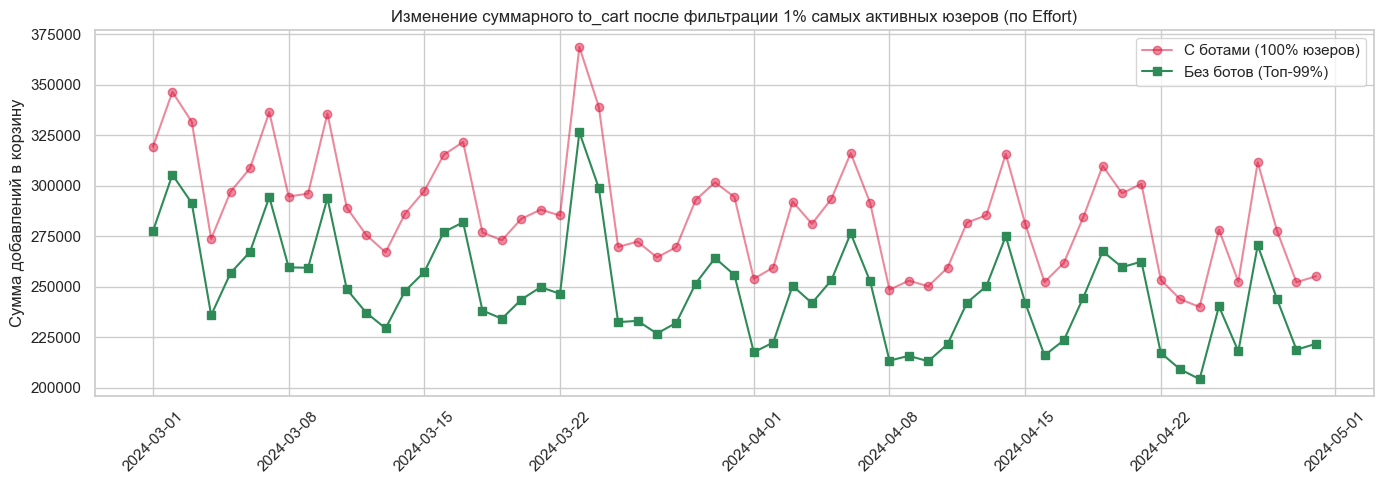

In [5]:
user_activity = df_res.group_by('user_id').agg(
    pl.col('Effort').sum().alias('total_effort')
)

threshold_99 = user_activity['total_effort'].quantile(0.995)
print(f"Граница отсечения ботов (99-й перцентиль Effort): {threshold_99:.2f}")

normal_users_df = user_activity.filter(pl.col('total_effort') <= threshold_99).select('user_id')
print(f"Всего юзеров: {len(user_activity)}, Нормальных: {len(normal_users_df)}")
print(f"Отсечено ботов: {len(user_activity) - len(normal_users_df)}")

df_clean = df_res.join(normal_users_df, on='user_id', how='inner')

daily_all = (
    df_res.with_columns(pl.col('ts_end').dt.date().alias('date'))
          .group_by('date').agg(pl.col('n_cart').sum().alias('to_cart_total'))
          .sort('date')
)

daily_clean = (
    df_clean.with_columns(pl.col('ts_end').dt.date().alias('date'))
            .group_by('date').agg(pl.col('n_cart').sum().alias('to_cart_total'))
            .sort('date')
)

plt.figure(figsize=(14, 5))
plt.plot(daily_all['date'].to_list(), daily_all['to_cart_total'].to_list(), 
         label='С ботами (100% юзеров)', color='crimson', marker='o', alpha=0.5)

plt.plot(daily_clean['date'].to_list(), daily_clean['to_cart_total'].to_list(), 
         label='Без ботов (Топ-99%)', color='seagreen', marker='s')

plt.title('Изменение суммарного to_cart после фильтрации 1% самых активных юзеров (по Effort)')
plt.ylabel('Сумма добавлений в корзину')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

вывод: срезаем сильных пользователей - подход не подходит

# 1.2 Consistency check

Запускаем бутстрэп (симуляцию 2000 выборок)
 Прогресс: 100% (2000 из 2000)
 Бутстрэп завершен! Рисуем график 


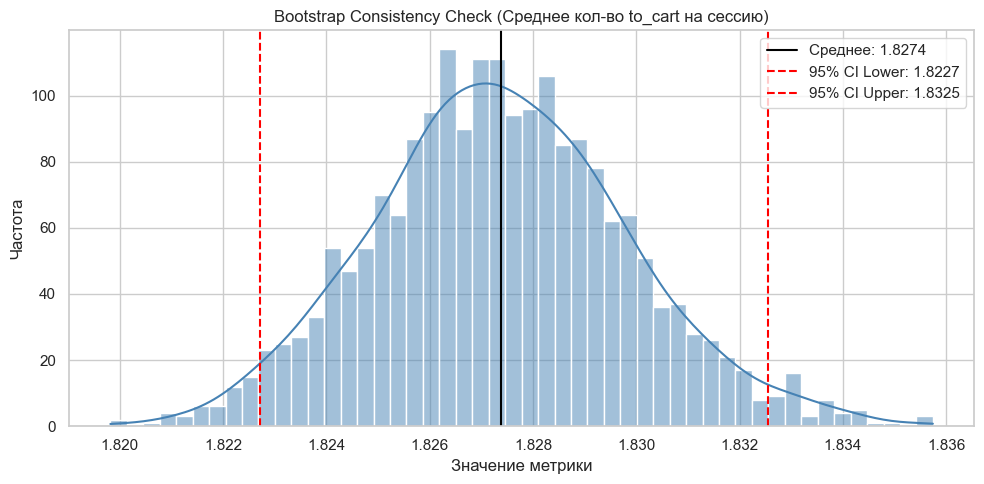

Метрика стабильна. 95% доверительный интервал:[1.8227, 1.8325]


In [6]:
print("Запускаем бутстрэп (симуляцию 2000 выборок)")

metric_array = df_clean['n_cart'].to_numpy()

n_bootstraps = 2000
bootstrapped_means = np.zeros(n_bootstraps)
rng = np.random.default_rng(42)

for i in range(n_bootstraps):
    sample = rng.choice(metric_array, size=len(metric_array), replace=True)
    bootstrapped_means[i] = np.mean(sample)
    if (i + 1) % 20 == 0: 
        progress = (i + 1) / n_bootstraps * 100
        print(f"\r Прогресс: {progress:.0f}% ({i+1} из {n_bootstraps})", end="")

print("\n Бутстрэп завершен! Рисуем график ")
ci_lower = np.percentile(bootstrapped_means, 2.5)
ci_upper = np.percentile(bootstrapped_means, 97.5)
mean_val = np.mean(bootstrapped_means)

plt.figure(figsize=(10, 5))
sns.histplot(bootstrapped_means, bins=50, kde=True, color='steelblue')

plt.axvline(mean_val, color='black', linestyle='-', label=f'Среднее: {mean_val:.4f}')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'95% CI Lower: {ci_lower:.4f}')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'95% CI Upper: {ci_upper:.4f}')

plt.title('Bootstrap Consistency Check (Среднее кол-во to_cart на сессию)')
plt.xlabel('Значение метрики')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Метрика стабильна. 95% доверительный интервал:[{ci_lower:.4f}, {ci_upper:.4f}]")

бутстреп рабочий


# 1.3 Bot scorer

In [ ]:
import polars as pl
import numpy as np
import pandas as pd
import itertools
from pathlib import Path

# ==============================================================================
# ШАГ 1: Подготовка данных на уровне ЮЗЕРА (Баним целиком)
# ==============================================================================
print("1. Подготовка данных: агрегация по юзерам...")

df_res = pl.read_parquet("../../data/intent_sessions_scored.parquet")

user_activity = df_res.group_by('user_id').agg([
    pl.col('n_events').sum().alias('n_events'),
    pl.col('n_search').sum().alias('n_search'),
    pl.col('n_view').sum().alias('n_view'),
    pl.col('n_click').sum().alias('n_click'),
    pl.col('n_cart').sum().alias('n_cart'),
    pl.col('reached_cart').cast(pl.Int32).max().alias('reached_cart')
])

baseline_n_cart = user_activity['n_cart'].mean()
baseline_reached = user_activity['reached_cart'].mean()

# ==============================================================================
# ШАГ 2: Настройка Grid Search (Перебор весов)
# ==============================================================================
print("2. Генерация сетки весов...")

weight_options = [1, 2, 3]
columns =['n_unique_queries', 'n_view', 'n_view', 'n_click', 'n_cart']

all_combinations = list(itertools.product(weight_options, repeat=5))
total_combinations = len(all_combinations)

print(f"   Сгенерировано комбинаций: {total_combinations}")

# ==============================================================================
# ШАГ 3: Запуск тяжелых вычислений (Grid Search + Bootstrap)
# ==============================================================================
print("\n3. Запуск Grid Search и Бутстрэпа (это займет время)...")

n_bootstraps = 500
rng = np.random.default_rng(42)
results =[]

for idx, weights_tuple in enumerate(all_combinations):
    w_events, w_search, w_view, w_click, w_cart = weights_tuple

    score_expr = (
        (pl.col('n_events') * w_events) +
        (pl.col('n_search') * w_search) +
        (pl.col('n_view') * w_view) +
        (pl.col('n_click') * w_click) +
        (pl.col('n_cart') * w_cart)
    )
    scored_users = user_activity.with_columns(score_expr.alias('bot_score'))

    threshold = scored_users['bot_score'].quantile(0.99)
    clean_users = scored_users.filter(pl.col('bot_score') <= threshold)

    clean_n_cart = clean_users['n_cart'].mean()
    clean_reached = clean_users['reached_cart'].mean()

    drop_n_cart_pct = (clean_n_cart - baseline_n_cart) / baseline_n_cart * 100
    drop_reached_pct = (clean_reached - baseline_reached) / baseline_reached * 100

    metric_arr = clean_users['n_cart'].to_numpy()
    boot_means = np.zeros(n_bootstraps)

    for i in range(n_bootstraps):
        sample = rng.choice(metric_arr, size=len(metric_arr), replace=True)
        boot_means[i] = np.mean(sample)

    std_val = np.std(boot_means)

    results.append({
        "Веса (events, search, view, click, cart)": f"{w_events}, {w_search}, {w_view}, {w_click}, {w_cart}",
        "STD (Меньше = Лучше)": std_val,
        "n_cart Change %": drop_n_cart_pct,
        "reached_cart Change %": drop_reached_pct
    })

    pct = (idx + 1) / total_combinations * 100
    print(f"\r Считаем: {pct:.1f}% | Проверено: {idx + 1} / {total_combinations} формул", end="")

print("\n Вычисления успешно завершены!")

# ==============================================================================
# ШАГ 4: Вывод результатов
# ==============================================================================
results_df = pd.DataFrame(results).sort_values("STD (Меньше = Лучше)").reset_index(drop=True)

print("\n ТОП-10 ИДЕАЛЬНЫХ ФОРМУЛ БОТ-СКОРЕРА (По стабильности метрики):")
print("Обрати внимание на колонки Change %: они не должны падать слишком сильно (не больше -5% / -10%)")
display(results_df.head(10))

results_df.to_csv('bot_scorer_grid_results.csv', index=False)
print("\n Полные результаты сохранены в файл: bot_scorer_grid_results.csv") 

1. Подготовка данных: агрегация по юзерам...
2. Генерация сетки весов...
   Сгенерировано комбинаций: 243

3. Запуск Grid Search и Бутстрэпа (это займет время)...
 Считаем: 46.1% | Проверено: 112 / 243 формул

KeyboardInterrupt: 

# 1.4 Session-level фильтр: аномальная активность без конверсии

**Идея**: фильтруем сессии, а не юзеров. Если у пользователя была одна странная сессия — это не делает его ботом навсегда; остальные его сессии остаются в метрике.

**Бот-сессия** = high activity + low cart conversion в этой конкретной сессии:
1. **Volume gate**: `n_search + n_view >= p99.8` сессий — топ 0.2% по объёму
2. **Conversion gate**: среди них — те, у которых `n_cart / activity` ниже медианы

Преимущество vs user-level подхода (Прохор 1.1, 1.3):
- юзер с 1 странной сессией из 10 теряет только эту сессию, не все 10
- активные **реальные** покупатели не отрезаются за высокую активность
- бот-фермы где 1 user = много фейковых сессий — каждая сессия проверяется отдельно

In [ ]:
df = df_res.with_columns([
    (pl.col('n_search').fill_null(0) + pl.col('n_view').fill_null(0)).alias('activity'),
])
df = df.with_columns([
    (pl.col('n_cart').fill_null(0) / pl.max_horizontal(pl.col('activity'), pl.lit(1)))
    .alias('cart_per_activity'),
])

activity = df['activity'].to_numpy()
n_cart   = df['n_cart'].fill_null(0).to_numpy()
cpa      = df['cart_per_activity'].to_numpy()
N = len(df)
baseline = n_cart.mean()

print('Распределение session activity (n_search + n_view):')
for q in [0.5, 0.9, 0.95, 0.99, 0.998, 0.999, 0.9999]:
    print(f'  p{q*100:>6.2f}: {np.quantile(activity, q):>8.0f}')
print(f'max:    {activity.max():>8.0f}')
print(f'baseline mean(n_cart) per session: {baseline:.4f}\n')

# Sensitivity grid: volume gate и conversion gate
VOL_PS  = [0.9999, 0.999, 0.998, 0.995, 0.99, 0.95]
CONV_PS = [0.05, 0.10, 0.20, 0.50, 1.00]   # 1.00 = без conv-гейта (только volume)

print(f'{"vol_p":>7} {"conv_p":>7} {"sessions":>10} {"%sess":>8} {"users":>8} {"Δn_cart":>9}')
print('-'*60)
for vol_p in VOL_PS:
    high = activity >= np.quantile(activity, vol_p)
    for conv_p in CONV_PS:
        if conv_p == 1.00:
            bot = high
        else:
            bot = high & (cpa <= np.quantile(cpa[high], conv_p))
        d = (n_cart[~bot].mean() - baseline) / baseline * 100
        users_aff = df.filter(pl.Series(bot))['user_id'].n_unique() if bot.sum() else 0
        print(f'{vol_p:>7.4f} {conv_p:>7.2f} {bot.sum():>10,} '
              f'{bot.sum()/N*100:>7.3f}% {users_aff:>8,} {d:>+8.2f}%')
    print()  #

# Default
VOL_P, CONV_P = 0.998, 0.50
high = activity >= np.quantile(activity, VOL_P)
bot_sess_mask = high & (cpa <= np.quantile(cpa[high], CONV_P))
print(f'\nВыбрано: vol>p{VOL_P*100:.1f} * conv<median')
print(f'  → {bot_sess_mask.sum():,} сессий ({bot_sess_mask.sum()/N*100:.3f}% от всех)')

Распределение session activity (n_search + n_view):
  p 50.00:       25
  p 90.00:      141
  p 95.00:      209
  p 99.00:      395
  p 99.80:      624
  p 99.90:      738
  p 99.99:     1196
  max:     3274063

baseline mean(n_cart) per session: 1.9385

  vol_p  conv_p   sessions    %sess    users   Δn_cart
------------------------------------------------------------
 0.9999    0.05         69   0.001%       57    +0.00%
 0.9999    0.10         91   0.001%       78    +0.00%
 0.9999    0.20        181   0.002%      152    -0.31%
 0.9999    0.50        453   0.005%      405    -0.32%
 0.9999    1.00        905   0.010%      782    -0.41%

 0.9990    0.05        453   0.005%      419    +0.00%
 0.9990    0.10        906   0.010%      835    -0.19%
 0.9990    0.20      1,813   0.020%    1,681    -0.32%
 0.9990    0.50      4,529   0.050%    4,083    -0.46%
 0.9990    1.00      9,058   0.100%    7,765    -1.15%

 0.9980    0.05        906   0.010%      849    +0.01%
 0.9980    0.10      1

## Сколько юзеров не теряем благодаря session-level подходу

Если у юзера 1 bot-сессия из 10 нормальных — user-level выбросил бы его целиком (потеря 10 сессий).
Session-level — выбросит только 1 (потеря 1 из 10).

Считаем распределение bot-сессий на юзера: если у большинства affected-юзеров только **1** bot-сессия,
а остальные нормальные — это и есть тот случай, когда session-level правильнее.

In [21]:
bot_per_user = (
    df.filter(pl.Series(bot_sess_mask))
      .group_by('user_id').agg(pl.len().alias('n_bot'))
      .sort('n_bot', descending=True)
)
total_per_user = (
    df.group_by('user_id').agg(pl.len().alias('n_total'))
)
joined = bot_per_user.join(total_per_user, on='user_id', how='left').to_pandas()
joined['bot_share'] = joined['n_bot'] / joined['n_total']

print(f'Юзеров с хотя бы одной bot-session: {len(joined):,}')
print(f'У них среднее всех сессий:           {joined["n_total"].mean():.2f}')
print(f'У них среднее bot-сессий:            {joined["n_bot"].mean():.2f}')
print(f'Среднее bot_share (доля bot из всех его сессий): {joined["bot_share"].mean():.3f}\n')

print('Распределение числа bot-сессий на юзера:')
print(joined['n_bot'].value_counts().sort_index().head(10).to_string())

# Сколько НЕ теряем благодаря session-level
total_sessions_of_affected = joined['n_total'].sum()
bot_sessions_of_affected = joined['n_bot'].sum()
saved_sessions = total_sessions_of_affected - bot_sessions_of_affected
print(f'\nКонкретно: у этих {len(joined)} юзеров всего {total_sessions_of_affected:,} сессий.')
print(f'Из них bot: {bot_sessions_of_affected:,}, normal: {saved_sessions:,}')
print(f'  → user-level выкинул бы все {total_sessions_of_affected:,}')
print(f'  → session-level выкидывает только {bot_sessions_of_affected:,} (сохранили {saved_sessions:,} сессий)')

Юзеров с хотя бы одной bot-session: 7,971
У них среднее всех сессий:           16.88
У них среднее bot-сессий:            1.14
Среднее bot_share (доля bot из всех его сессий): 0.211

Распределение числа bot-сессий на юзера:
n_bot
1     7279
2      503
3      116
4       35
5       16
6        6
7        3
8        2
9        3
10       1

Конкретно: у этих 7971 юзеров всего 134,517 сессий.
Из них bot: 9,055, normal: 125,462
  → user-level выкинул бы все 134,517
  → session-level выкидывает только 9,055 (сохранили 125,462 сессий)


## Сравнение с Effort-фильтром (1.1)

Effort режет 1% юзеров (≈26К) → теряем все их сессии (~миллион сессий).
Session-level режет ~0.1% сессий точечно (~9К сессий).

In [ ]:
# Effort: топ-1% по total_effort per user
user_effort = df.group_by('user_id').agg(pl.col('Effort').sum().alias('total_effort'))
threshold_99 = user_effort['total_effort'].quantile(0.99)
effort_users = user_effort.filter(pl.col('total_effort') > threshold_99)['user_id']
df_clean_effort = df.join(
    pl.DataFrame({'user_id': effort_users.to_numpy()}),
    on='user_id', how='anti'
)

n_eff_users = len(effort_users)
n_eff_sess  = len(df) - len(df_clean_effort)

n_new_users = df.filter(pl.Series(bot_sess_mask))['user_id'].n_unique()
n_new_sess  = bot_sess_mask.sum()

print('                       юзеров затронуто  сессий удалено')
print(f'Effort (1.1, user-lvl):   {n_eff_users:>8,}        {n_eff_sess:>8,}')
print(f'Vol×Conv (1.4, sess-lvl): {n_new_users:>8,}        {n_new_sess:>8,}')
print(f'\nЭкономия сессий (session-level vs user-level): {n_eff_sess - n_new_sess:,}')

## Downstream impact: дневная стабильность

In [ ]:
df_clean_new = df.filter(~pl.Series(bot_sess_mask))

daily_before = (df.with_columns(pl.col('ts_end').dt.date().alias('d'))
                .group_by('d').agg(pl.col('n_cart').mean().alias('m')).sort('d'))
daily_new = (df_clean_new.with_columns(pl.col('ts_end').dt.date().alias('d'))
             .group_by('d').agg(pl.col('n_cart').mean().alias('m')).sort('d'))
daily_eff = (df_clean_effort.with_columns(pl.col('ts_end').dt.date().alias('d'))
             .group_by('d').agg(pl.col('n_cart').mean().alias('m')).sort('d'))

m1, s1 = daily_before['m'].mean(), daily_before['m'].std()
m2, s2 = daily_new['m'].mean(),    daily_new['m'].std()
m3, s3 = daily_eff['m'].mean(),    daily_eff['m'].std()
print('Daily mean(n_cart):')
print(f'  ДО:                  mean={m1:.4f}  std={s1:.5f}  CV={s1/m1:.4f}')
print(f'  Effort (user-lvl):   mean={m3:.4f}  std={s3:.5f}  CV={s3/m3:.4f}  Δstd={(s3-s1)/s1*100:+.1f}%')
print(f'  Vol-Conv (sess-lvl): mean={m2:.4f}  std={s2:.5f}  CV={s2/m2:.4f}  Δstd={(s2-s1)/s1*100:+.1f}%')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_before['d'].to_list(), daily_before['m'].to_list(),
        marker='o', label=f'до (std={s1:.4f})', color='crimson', alpha=0.7)
ax.plot(daily_eff['d'].to_list(), daily_eff['m'].to_list(),
        marker='s', label=f'Effort 1% user-lvl (std={s3:.4f})', color='orange', alpha=0.7)
ax.plot(daily_new['d'].to_list(), daily_new['m'].to_list(),
        marker='^', label=f'Vol×Conv 0.1% sess-lvl (std={s2:.4f})', color='seagreen')
ax.set_title('Daily mean(n_cart): user-level vs session-level фильтр')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Выводы
В текущих подходах невозможно адекватно провалидировать: бот или powerful user. В связи с этим попробуем сглаживать потенциальные выбросы при построении самой метрики. Trade off должен быть рабочий так как бот активность вероятнее всего не дает слишком разного вклада ото дня ко дню. Используем index-realtive метрики, полезно использовать median или binary вместо mean в daily summary